In [2]:
!pip install bibtexparser pandas openpyxl matplotlib wordcloud

In [3]:
import bibtexparser

with open("corpus_eixo1_negros_v2.bib", encoding="utf-8") as bibtex_file:
    bib_database = bibtexparser.load(bibtex_file)

print("Total de registros:", len(bib_database.entries))

Total de registros: 94


In [4]:
print(bib_database.entries[0])

{'keywords': '', 'doi': '10.15448/1984-7726.2023.1.44728', 'pages': 'e44728-e44728', 'number': '', 'volume': '', 'year': '2024', 'journal': 'Letras de Hoje', 'author': 'Suéllen Stéfani Felício Lourenço, Mariana Ramalho Procópio, Ana Carolina Gonçalves Reis', 'title': 'representação da pessoa negra na publicidade contemporânea brasileira', 'ENTRYTYPE': 'article', 'ID': 'W4390691902'}


In [5]:
campos = set()

for artigo in bib_database.entries:
    campos.update(artigo.keys())

print(sorted(campos))

['ENTRYTYPE', 'ID', 'author', 'doi', 'journal', 'keywords', 'number', 'pages', 'title', 'volume', 'year']


In [6]:
for campo in sorted(campos):
    preenchidos = sum(
        1 for artigo in bib_database.entries
        if artigo.get(campo)
    )

    print(f"{campo}: {preenchidos}")

ENTRYTYPE: 94
ID: 94
author: 94
doi: 92
journal: 94
keywords: 0
number: 78
pages: 94
title: 94
volume: 77
year: 94


In [7]:
df[["Titulo","Periodico"]].head(20)

NameError: name 'df' is not defined

In [8]:
import pandas as pd

dados = []

for artigo in bib_database.entries:
    dados.append({
        "Titulo": artigo.get("title", ""),
        "Autores": artigo.get("author", ""),
        "Ano": artigo.get("year", ""),
        "Periodico": artigo.get("journal", ""),
        "DOI": artigo.get("doi", "")
    })

df = pd.DataFrame(dados)

print(df.shape)

df.head()

(94, 5)


,Titulo,Autores,Ano,Periodico,DOI
0,representação da pessoa negra na publicidade c...,"Suéllen Stéfani Felício Lourenço, Mariana Rama...",2024,Letras de Hoje,10.15448/1984-7726.2023.1.44728
1,DisCrit: os limites da interseccionalidade par...,"Philippe Oliveira de Almeida, Luana Adriano Ar...",2020,Revista Brasileira de Políticas Públicas,10.5102/rbpp.v10i2.6861
2,A (in)visibilidade de pessoas negras na public...,"Ana Paula Bragaglia, Pedro Henrique Conceição ...",2020,Esferas,10.31501/esf.v0i18.11934
3,A Considerações sobre a representação da pesso...,"Suéllen Stéfani Felício Lourenço, Mariana Rama...",2024,Letras de Hoje,10.15448/1984-7726.2024.1.44728
4,Relações raciais e histórias de vida: trabalha...,"Matheus Arcelo Fernandes Silva, Luiz Alex Silv...",2020,Organizações &amp; Sociedade,10.1590/1984-9270947


In [9]:
df[["Titulo","Periodico"]].head(20)

,Titulo,Periodico
0,representação da pessoa negra na publicidade c...,Letras de Hoje
1,DisCrit: os limites da interseccionalidade par...,Revista Brasileira de Políticas Públicas
2,A (in)visibilidade de pessoas negras na public...,Esferas
3,A Considerações sobre a representação da pesso...,Letras de Hoje
4,Relações raciais e histórias de vida: trabalha...,Organizações &amp; Sociedade
5,Visões sobre o Movimento Black Rio: apontament...,Animus Revista Interamericana de Comunicação M...
6,Mandume: a oralidade e a memória cultural na c...,SHILAP Revista de lepidopterología
7,O currículo da educação superior e a Ressignif...,Revista Internacional de Educação Superior
8,Análise da atenção visual aos modelos negro e ...,Esferas
9,Nos cruzamentos das avenidas identitárias há a...,Revista FAMECOS


In [10]:
df["Periodico"].value_counts().head(30)

,count
Periodico,
Animus Revista Interamericana de Comunicação Midiática,3
Letras de Hoje,2
SHILAP Revista de lepidopterología,2
Esferas,2
Revista FAMECOS,2
Revista Thesis Juris,2
Saúde e Sociedade,2
Diversidade e Educação,2
Galáxia (São Paulo),2


In [12]:
periodicos_excluir = [
    "Revista Brasileira de Enfermagem",
    "Psicologia & Sociedade",
    "Cadernos de Saúde Pública"
]

In [13]:
df["Periodico"].value_counts().head(30)

,count
Periodico,
Animus Revista Interamericana de Comunicação Midiática,3
Letras de Hoje,2
SHILAP Revista de lepidopterología,2
Esferas,2
Revista FAMECOS,2
Revista Thesis Juris,2
Saúde e Sociedade,2
Diversidade e Educação,2
Galáxia (São Paulo),2


In [14]:
df[df["Periodico"].str.contains(
    "Saúde|Juris|Lepidopter",
    case=False,
    na=False
)][["Titulo","Periodico"]]

,Titulo,Periodico
6,Mandume: a oralidade e a memória cultural na c...,SHILAP Revista de lepidopterología
13,Racializando o olhar (sociológico) sobre a saú...,Saúde e Sociedade
17,Reconhecimento como igualdade e diferença na c...,Revista Thesis Juris
33,As semioses do “tornar-se” negra em “Mulheres ...,SHILAP Revista de lepidopterología
40,A netnografia da representatividade negra numa...,Tempus Actas de Saúde Coletiva
54,"30 anos após a intervenção no Anchieta, por on...",Saúde e Sociedade
68,Conhecimento científico como instrumento para ...,Revista Thesis Juris


In [15]:
df.to_excel("corpus_completo.xlsx", index=False)

print("Arquivo salvo!")

Arquivo salvo!


In [16]:
df["Ano"].value_counts().sort_index()

,count
Ano,
2015,3
2016,4
2017,4
2018,4
2019,7
2020,17
2021,15
2022,15
2023,12


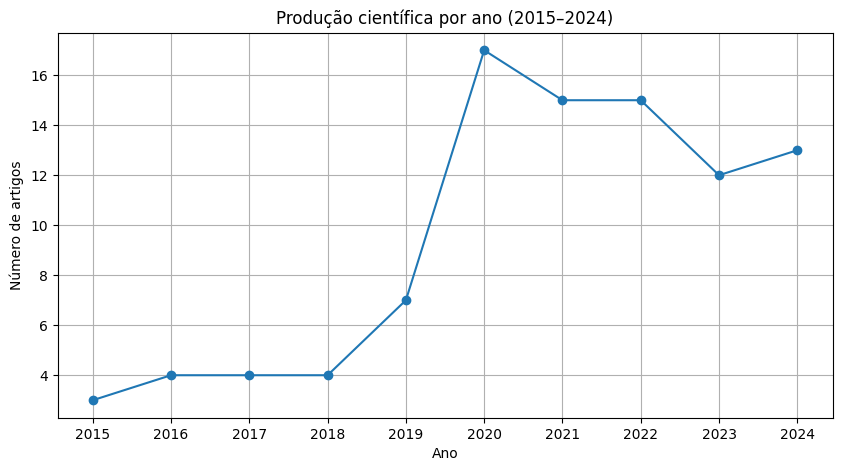

In [17]:
import matplotlib.pyplot as plt

producao = df["Ano"].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.plot(
    producao.index,
    producao.values,
    marker="o"
)

plt.title("Produção científica por ano (2015–2024)")
plt.xlabel("Ano")
plt.ylabel("Número de artigos")

plt.grid(True)

plt.show()

In [18]:
from collections import Counter
import pandas as pd

texto = " ".join(df["Titulo"].astype(str))

texto = texto.lower()

texto = texto.replace(",", " ")
texto = texto.replace(".", " ")
texto = texto.replace(":", " ")
texto = texto.replace(";", " ")
texto = texto.replace("-", " ")

stopwords = {
    "de","da","do","das","dos",
    "a","o","as","os",
    "e","em","na","no","nas","nos",
    "para","por","com","um","uma",
    "sobre","entre","como","ao","aos",
    "à","às"
}

palavras = [
    p for p in texto.split()
    if len(p) > 3 and p not in stopwords
]

frequencia = Counter(palavras)

top20 = pd.DataFrame(
    frequencia.most_common(20),
    columns=["Palavra","Frequencia"]
)

top20

,Palavra,Frequencia
0,negra,16
1,análise,8
2,identidade,7
3,negro,7
4,negras,6
5,educação,6
6,negros,5
7,racismo,5
8,pessoa,4
9,publicidade,4


In [20]:
texto = " ".join(df["Titulo"].astype(str)).lower()

substituicoes = {
    "negra": "negro",
    "negras": "negro",
    "negros": "negro",
    "brasileira": "brasil",
    "brasileiro": "brasil",
    "brasileiras": "brasil",
    "brasileiros": "brasil"
}

for antigo, novo in substituicoes.items():
    texto = texto.replace(antigo, novo)

stopwords = {
    "de","da","do","das","dos",
    "a","o","as","os",
    "e","em","na","no","nas","nos",
    "para","por","com","um","uma",
    "sobre","entre","como","análise",
    "estudo","olhar","partir"
}

from collections import Counter

palavras = [
    p for p in texto.split()
    if len(p) > 3 and p not in stopwords
]

freq = Counter(palavras)

top15 = pd.DataFrame(
    freq.most_common(15),
    columns=["Palavra","Frequencia"]
)

top15

,Palavra,Frequencia
0,negro,31
1,brasil,10
2,identidade,6
3,educação,6
4,pessoa,4
5,relações,4
6,movimento,4
7,construção,4
8,racismo,4
9,sociais,4


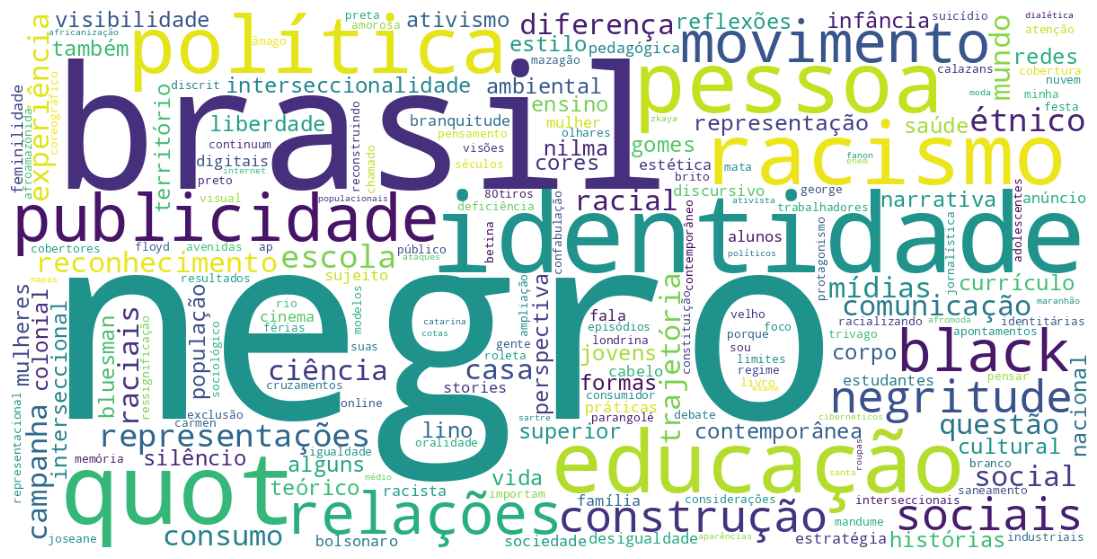

In [21]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
)

wc.generate(" ".join(palavras))

plt.figure(figsize=(14,7))
plt.imshow(wc)
plt.axis("off")
plt.show()

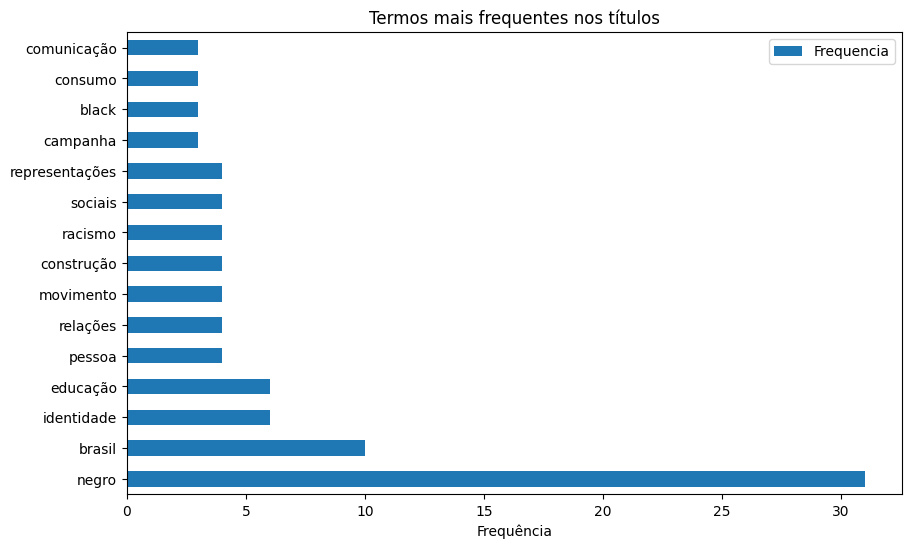

In [22]:
top15.plot(
    kind="barh",
    x="Palavra",
    y="Frequencia",
    figsize=(10,6)
)

plt.title("Termos mais frequentes nos títulos")
plt.xlabel("Frequência")
plt.ylabel("")

plt.show()

In [23]:
from collections import Counter

lista_autores = []

for autores in df["Autores"]:

    autores_separados = autores.split(",")

    for autor in autores_separados:
        lista_autores.append(autor.strip())

freq_autores = Counter(lista_autores)

top_autores = pd.DataFrame(
    freq_autores.most_common(20),
    columns=["Autor","Publicacoes"]
)

top_autores

,Autor,Publicacoes
0,Pablo Moreno Fernandes,5
1,Suéllen Stéfani Felício Lourenço,2
2,Ana Carolina Gonçalves Reis,2
3,Luciana Xavier de Oliveira,2
4,Leandro Leonardo Batista,2
5,Dalila Maria Musa Belmiro,2
6,Fernanda Wanderer,2
7,Mariana Ramalho Procópio,1
8,Philippe Oliveira de Almeida,1
9,Luana Adriano Araújo,1


In [24]:
from collections import Counter

lista_autores = []

for autores in df["Autores"]:

    autores_separados = autores.split(",")

    for autor in autores_separados:
        lista_autores.append(autor.strip())

freq_autores = Counter(lista_autores)

top_autores = pd.DataFrame(
    freq_autores.most_common(20),
    columns=["Autor","Publicacoes"]
)

top_autores

,Autor,Publicacoes
0,Pablo Moreno Fernandes,5
1,Suéllen Stéfani Felício Lourenço,2
2,Ana Carolina Gonçalves Reis,2
3,Luciana Xavier de Oliveira,2
4,Leandro Leonardo Batista,2
5,Dalila Maria Musa Belmiro,2
6,Fernanda Wanderer,2
7,Mariana Ramalho Procópio,1
8,Philippe Oliveira de Almeida,1
9,Luana Adriano Araújo,1


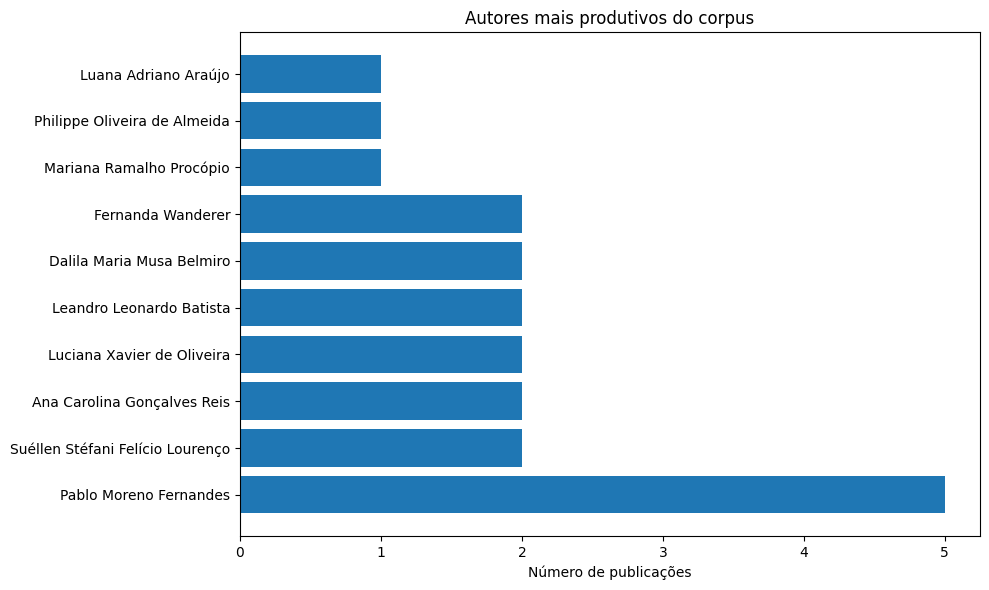

In [25]:
import matplotlib.pyplot as plt

top10 = top_autores.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Autor"],
    top10["Publicacoes"]
)

plt.title("Autores mais produtivos do corpus")
plt.xlabel("Número de publicações")

plt.tight_layout()

plt.show()

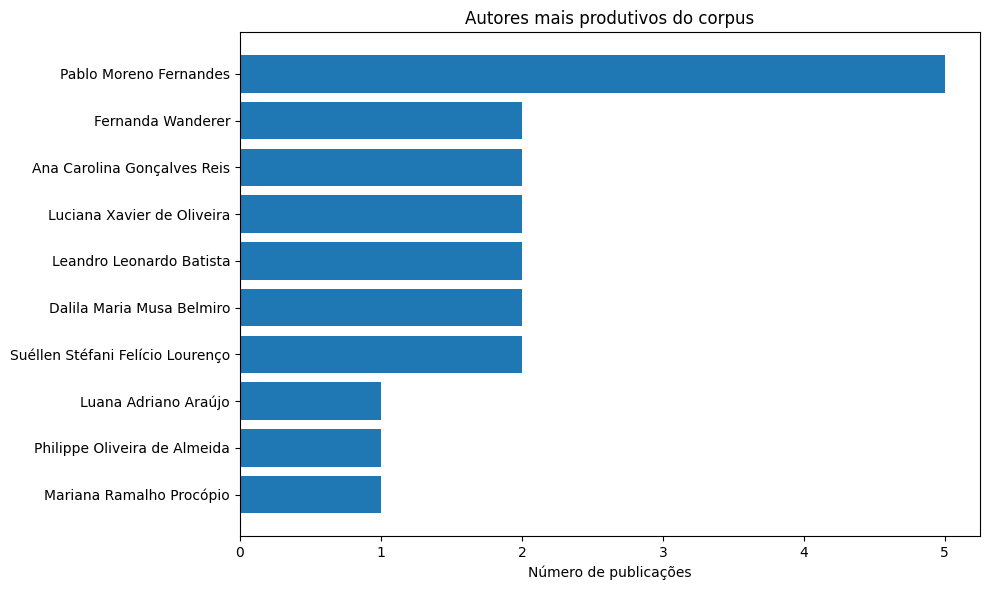

In [26]:
top10_ordenado = top_autores.head(10).sort_values(
    by="Publicacoes",
    ascending=True
)

plt.figure(figsize=(10,6))

plt.barh(
    top10_ordenado["Autor"],
    top10_ordenado["Publicacoes"]
)

plt.title("Autores mais produtivos do corpus")
plt.xlabel("Número de publicações")

plt.tight_layout()

plt.show()

In [27]:
top_periodicos = (
    df["Periodico"]
    .value_counts()
    .reset_index()
)

top_periodicos.columns = [
    "Periodico",
    "Publicacoes"
]

top_periodicos.head(15)

,Periodico,Publicacoes
0,Animus Revista Interamericana de Comunicação M...,3
1,Letras de Hoje,2
2,SHILAP Revista de lepidopterología,2
3,Esferas,2
4,Revista FAMECOS,2
5,Revista Thesis Juris,2
6,Saúde e Sociedade,2
7,Diversidade e Educação,2
8,Galáxia (São Paulo),2
9,CAMINHOS DA EDUCAÇÃO diálogos culturas e diver...,2


In [28]:
len(lista_autores)

183

In [29]:
len(set(lista_autores))

173

In [30]:
183 / 94

1.946808510638298

In [31]:
producao_ano = (
    df["Ano"]
    .value_counts()
    .sort_index()
    .reset_index()
)

producao_ano.columns = [
    "Ano",
    "Publicacoes"
]

producao_ano.to_excel(
    "producao_por_ano.xlsx",
    index=False
)

producao_ano

,Ano,Publicacoes
0,2015,3
1,2016,4
2,2017,4
3,2018,4
4,2019,7
5,2020,17
6,2021,15
7,2022,15
8,2023,12
9,2024,13


In [32]:
top_periodicos.to_excel(
    "periodicos_produtivos.xlsx",
    index=False
)

print("Arquivo salvo!")

Arquivo salvo!


In [33]:
df.to_excel("corpus_negros_completo.xlsx", index=False)
top_autores.to_excel("autores_negros.xlsx", index=False)
top_periodicos.to_excel("periodicos_negros.xlsx", index=False)
producao_ano.to_excel("producao_por_ano_negros.xlsx", index=False)